PYTHON
Project: Retail Sales Data with Seasonal Trends & Marketing (Kaggle)

1. Import Libraries and Load Data


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df = pd.read_csv('Retail and wherehouse Sale.csv')

In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              30000 non-null  int64  
 1   MONTH             30000 non-null  int64  
 2   SUPPLIER          29967 non-null  object 
 3   ITEM CODE         30000 non-null  object 
 4   ITEM DESCRIPTION  30000 non-null  object 
 5   ITEM TYPE         30000 non-null  object 
 6   RETAIL SALES      29999 non-null  float64
 7   RETAIL TRANSFERS  30000 non-null  float64
 8   WAREHOUSE SALES   30000 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.1+ MB
None


In [7]:
print(df.head())

   YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1  2020      1                          PWSWN INC    100024   
2  2020      1            RELIABLE CHURCHILL LLLP      1001   
3  2020      1          LANTERNA DISTRIBUTORS INC    100145   
4  2020      1               DIONYSOS IMPORTS INC    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  BOOTLEG RED - 750ML      WINE          0.00   
1            MOMENT DE PLAISIR - 750ML      WINE          0.00   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ      BEER          0.00   
3        SCHLINK HAUS KABINETT - 750ML      WINE          0.00   
4       SANTORINI GAVALA WHITE - 750ML      WINE          0.82   

   RETAIL TRANSFERS  WAREHOUSE SALES  
0               0.0              2.0  
1               1.0              4.0  
2               0.0              1.0  
3               0.0              1.0  
4               0.0          

2. Data Cleaning & Transformation

In [10]:
#Create a proper datetime column for time-series analysis
df['Date'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))

#Check for missing values
df = df.replace('Default', pd.NA)
df = df.dropna(subset=['SUPPLIER']) # Cleaning entries with no supplier

#Sort data by date
df = df.sort_values('Date')

3. Exploratory Data Analysis (EDA)

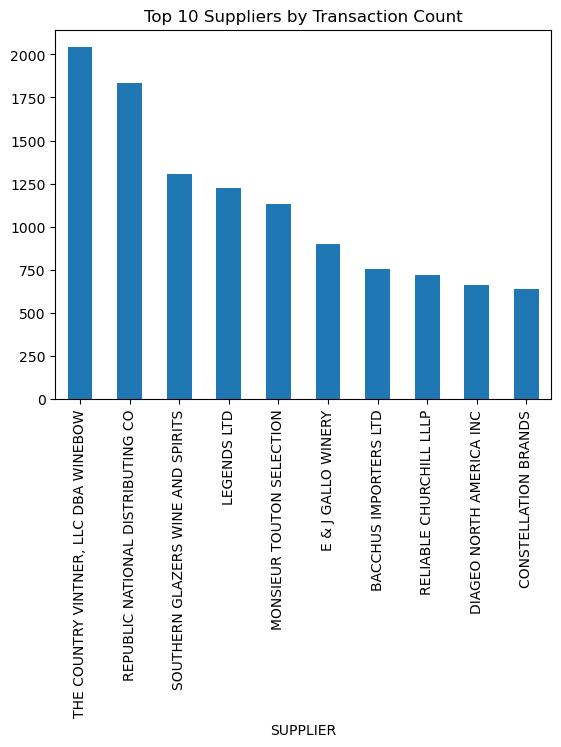

In [11]:
#Top Suppliers by Item Count

top_suppliers = df['SUPPLIER'].value_counts().head(10)
top_suppliers.plot(kind='bar', title='Top 10 Suppliers by Transaction Count')
plt.show()

Text(0.5, 1.0, 'Transaction Volume by Month')

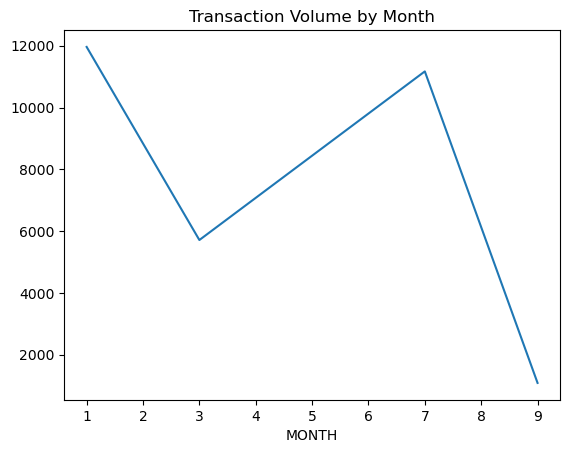

In [12]:
#Monthly Sales Trends

monthly_counts = df.groupby('MONTH').size()
sns.lineplot(data=monthly_counts).set_title('Transaction Volume by Month')

In [13]:
#export this cleaned data
df.to_csv('cleaned_retail_sales.csv', index=False)